**1. Data loading and exploration**

In [100]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns




from sklearn.linear_model import LinearRegression



In [101]:
# Load Data
df = pd.read_csv("streamworks_user_data.csv")
df.head(10)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99
5,1006.0,25.0,Male,25-06-23,13-07-25,USA,Premium,40.0,24.7,1.0,No,Yes,0.0,13.99
6,1007.0,38.0,Male,15-02-23,13-07-25,UK,Premium,57.8,83.9,0.0,No,Yes,0.0,14.99
7,1008.0,56.0,Male,20-12-22,13-07-25,Germany,Premium,9.0,35.6,5.0,No,Yes,0.0,14.99
8,1009.0,36.0,Other,30-05-25,13-07-25,UK,Standard,11.6,82.7,1.0,No,Yes,0.0,NaN
9,1010.0,40.0,Male,07-11-24,13-07-25,France,Basic,21.5,70.9,5.0,Yes,Yes,0.0,6.99


In [102]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


In [103]:
# Dataset Summary
df.describe()

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


In [104]:
# Missing Values
df.isnull().sum()

user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

In [105]:
# Target Variable: How many customers have left the platform
df["is_churned"].value_counts()

is_churned
0.0    1148
1.0     351
Name: count, dtype: int64

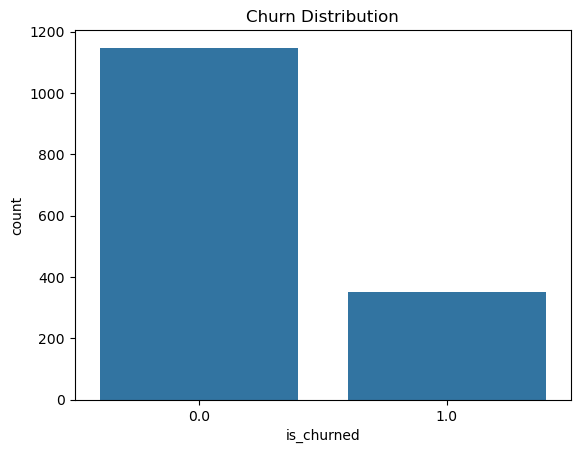

In [106]:
# The Chart
sns.countplot(data=df, x="is_churned")

plt.title("Churn Distribution")
plt.show()

*This chart shows the number of churned and retained users.*

In [107]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr()
corr

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
user_id,1.000000,-0.010213,-0.019042,-0.021341,-0.063852,0.001454,-0.054005
age,-0.010213,1.000000,0.036806,-0.009936,0.027707,0.002173,-0.001641
average_watch_hours,-0.019042,0.036806,1.000000,-0.004899,-0.013767,-0.004681,-0.021213
mobile_app_usage_pct,-0.021341,-0.009936,-0.004899,1.000000,-0.028562,0.016353,0.022061
complaints_raised,-0.063852,0.027707,-0.013767,-0.028562,1.000000,-0.005118,-0.033150
is_churned,0.001454,0.002173,-0.004681,0.016353,-0.005118,1.000000,-0.023976
monthly_fee,-0.054005,-0.001641,-0.021213,0.022061,-0.033150,-0.023976,1.000000


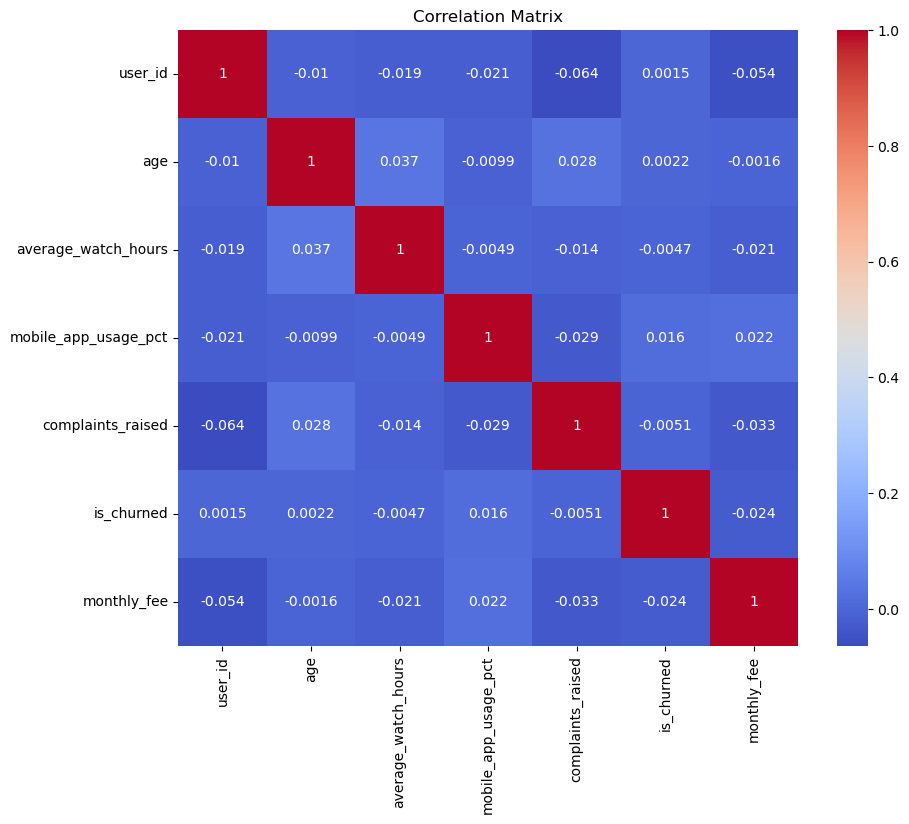

In [108]:
# Heatmap: 
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

*The heatmap shows the relationships between numerical variables.
Positive correlations appear in red and negative correlations in blue.*

**2. Data cleaning and preprocessing**

In [110]:
# Convert Date Columns
# Convert dates

df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_active_date"] = pd.to_datetime(df["last_active_date"])
df[["signup_date", "last_active_date"]].head(10)

,signup_date,last_active_date
0,2025-02-04,2025-07-13
1,2023-02-01,2025-07-13
2,2022-08-21,2025-07-13
3,2023-09-14,2025-07-13
4,2023-07-29,2025-07-13
5,2023-06-25,2025-07-13
6,2023-02-15,2025-07-13
7,2022-12-20,2025-07-13
8,2025-05-30,2025-07-13
9,2024-07-11,2025-07-13


*The signup_date and last_active_date columns were converted to datetime format to enable time calculations.*

**3. Feature engineering (e.g. new variables, encodings)**

In [111]:
# Create tenure_days
df["tenure_days"] = (df["last_active_date"] - df["signup_date"]).dt.days
df[["signup_date", "last_active_date", "tenure_days"]].head(10)

,signup_date,last_active_date,tenure_days
0,2025-02-04,2025-07-13,159.0
1,2023-02-01,2025-07-13,893.0
2,2022-08-21,2025-07-13,1057.0
3,2023-09-14,2025-07-13,668.0
4,2023-07-29,2025-07-13,715.0
5,2023-06-25,2025-07-13,749.0
6,2023-02-15,2025-07-13,879.0
7,2022-12-20,2025-07-13,936.0
8,2025-05-30,2025-07-13,44.0
9,2024-07-11,2025-07-13,367.0


*Created tenure_days, representing the number of days between signup and last activity.*

**Create is_loyal** according to the project: is_loyal = tenure_days > 180

In [112]:
df["is_loyal"] = df["tenure_days"] > 180
df[["tenure_days", "is_loyal"]].head(10)

,tenure_days,is_loyal
0,159.0,False
1,893.0,True
2,1057.0,True
3,668.0,True
4,715.0,True
5,749.0,True
6,879.0,True
7,936.0,True
8,44.0,False
9,367.0,True


In [113]:
# Check Missing Values
display(df.isnull().sum())

user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
tenure_days               4
is_loyal                  0
dtype: int64

*Missing values were identified before modelling.*

**Fill Missing Values**

In [114]:
# Numeric columns
numeric_columns = df.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Handle datetime columns
datetime_columns = df.select_dtypes(include=["datetime"]).columns
for col in datetime_columns:
    df[col] = df[col].fillna(pd.Timestamp("1900-01-01"))


# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

df.isnull().sum()

user_id                 0
age                     0
gender                  0
signup_date             0
last_active_date        0
country                 0
subscription_type       0
average_watch_hours     0
mobile_app_usage_pct    0
complaints_raised       0
received_promotions     0
referred_by_friend      0
is_churned              0
monthly_fee             0
tenure_days             0
is_loyal                0
dtype: int64

**Encode Yes / No Variables**

In [115]:
# received_promotions
df["received_promotions"] = (df["received_promotions"].map({"Yes":1, "No":0}))
print(df["received_promotions"])

0       0.0
1       0.0
2       0.0
3       1.0
4       0.0
       ... 
1495    0.0
1496    1.0
1497    0.0
1498    0.0
1499    0.0
Name: received_promotions, Length: 1500, dtype: float64


In [116]:
# referred_by_friend
df["referred_by_friend"] = (df["referred_by_friend"].map({"Yes":1, "No":0}))
print(df["referred_by_friend"] )

0       0.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1495    0.0
1496    1.0
1497    0.0
1498    1.0
1499    1.0
Name: referred_by_friend, Length: 1500, dtype: float64


**other preprocessing**

In [117]:
# Check available columns
print(df.columns)

Index(['user_id', 'age', 'gender', 'signup_date', 'last_active_date',
       'country', 'subscription_type', 'average_watch_hours',
       'mobile_app_usage_pct', 'complaints_raised', 'received_promotions',
       'referred_by_friend', 'is_churned', 'monthly_fee', 'tenure_days',
       'is_loyal'],
      dtype='object')


In [118]:
# Encode Gender
from sklearn.preprocessing import LabelEncoder

# Ensure column names are clean
df.columns = df.columns.str.strip()
encoder = LabelEncoder()
df["gender"] = encoder.fit_transform(df["gender"])

In [119]:
# One-Hot Encode Country
df = pd.get_dummies(df, columns=["country"], drop_first=True)

In [121]:
# One-hot encode the 'subscription_type' column
df = pd.get_dummies(df, columns=["subscription_type"], drop_first=True)

In [122]:
# Check the result after encoding and adding new columns
print(df.columns)

Index(['user_id', 'age', 'gender', 'signup_date', 'last_active_date',
       'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised',
       'received_promotions', 'referred_by_friend', 'is_churned',
       'monthly_fee', 'tenure_days', 'is_loyal', 'country_France',
       'country_Germany', 'country_India', 'country_UK', 'country_USA',
       'country_Unknown', 'subscription_type_Premium',
       'subscription_type_Standard', 'subscription_type_Unknown'],
      dtype='object')


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   user_id                     1500 non-null   float64       
 1   age                         1500 non-null   float64       
 2   gender                      1500 non-null   int64         
 3   signup_date                 1500 non-null   datetime64[ns]
 4   last_active_date            1500 non-null   datetime64[ns]
 5   average_watch_hours         1500 non-null   float64       
 6   mobile_app_usage_pct        1500 non-null   float64       
 7   complaints_raised           1500 non-null   float64       
 8   received_promotions         1497 non-null   float64       
 9   referred_by_friend          1497 non-null   float64       
 10  is_churned                  1500 non-null   float64       
 11  monthly_fee                 1500 non-null   float64     

**4. Summary tables and visualisations**

In [125]:
# Churn Distribution
# Number of churned vs retained users
churn_summary = df["is_churned"].value_counts(normalize=True) * 100
print(churn_summary)

is_churned
0.0    76.6
1.0    23.4
Name: proportion, dtype: float64


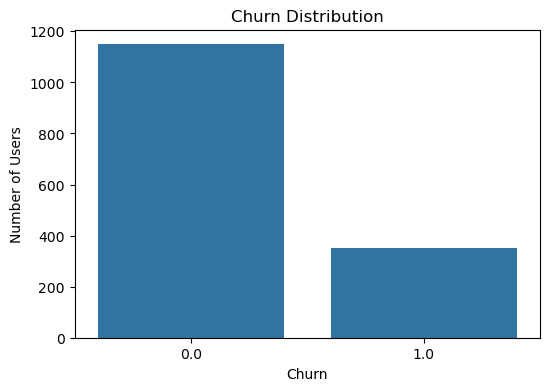

In [130]:
# Bar Plot – Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="is_churned")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Users")
plt.show()

In [126]:
# Average Watch Hours
watch_summary = df.groupby("is_churned")["average_watch_hours"].agg(["count", "mean", "median", "min", "max"])
watch_summary

,count,mean,median,min,max
is_churned,,,,,
0.0,1149,39.965709,40.3,0.5,79.7
1.0,351,39.703704,40.3,0.5,79.9


In [128]:
# Monthly Fee
fee_summary = df.groupby("is_churned")["monthly_fee"].agg(["mean", "median", "min", "max"])
fee_summary

,mean,median,min,max
is_churned,,,,
0.0,10.200618,9.99,5.99,14.99
1.0,10.035584,9.99,5.99,14.99


In [129]:
# Complaints
complaint_summary = df.groupby("is_churned")["complaints_raised"].mean()
complaint_summary

is_churned
0.0    2.502176
1.0    2.481481
Name: complaints_raised, dtype: float64

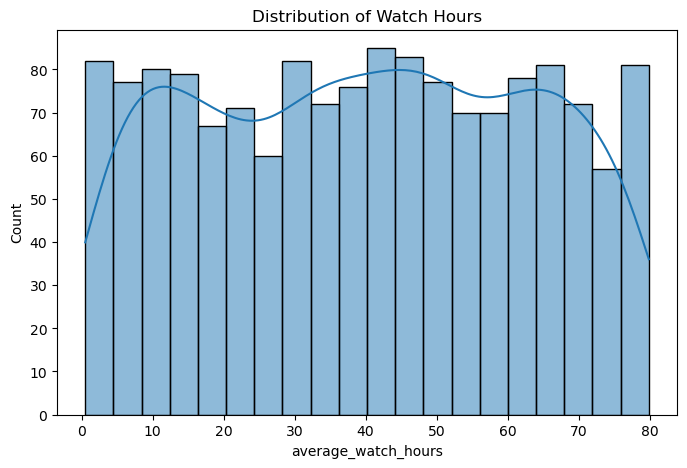

In [131]:
# Histogram – Average Watch Hours
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="average_watch_hours", bins=20, kde=True)
plt.title("Distribution of Watch Hours")
plt.show()

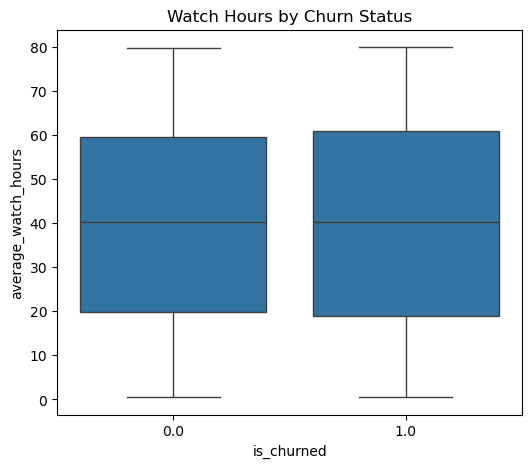

In [132]:
# Boxplot – Watch Hours vs Churn
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="is_churned", y="average_watch_hours")
plt.title("Watch Hours by Churn Status")
plt.show()

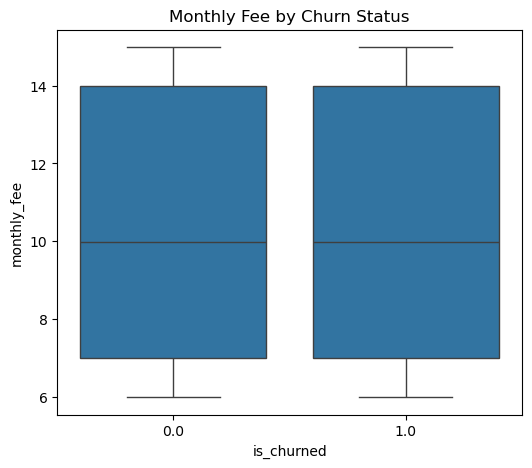

In [133]:
# Boxplot – Monthly Fee vs Churn
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="is_churned", y="monthly_fee")
plt.title("Monthly Fee by Churn Status")
plt.show()

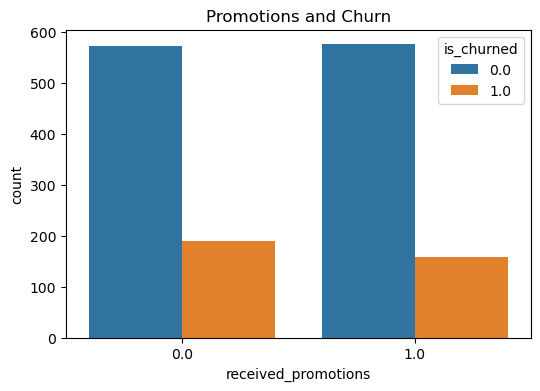

In [134]:
# Bar Plot – Promotions vs Churn
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="received_promotions", hue="is_churned")
plt.title("Promotions and Churn")
plt.show()

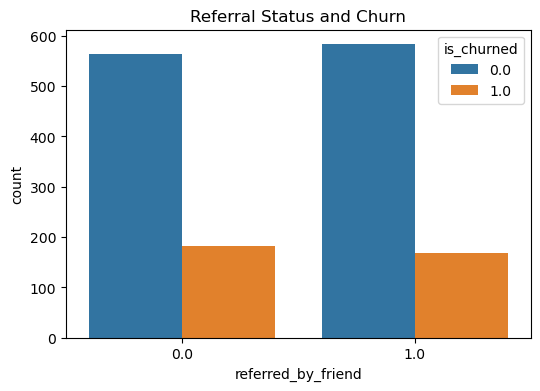

In [135]:
# Bar Plot – Referred by Friend
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="referred_by_friend", hue="is_churned")
plt.title("Referral Status and Churn")
plt.show()

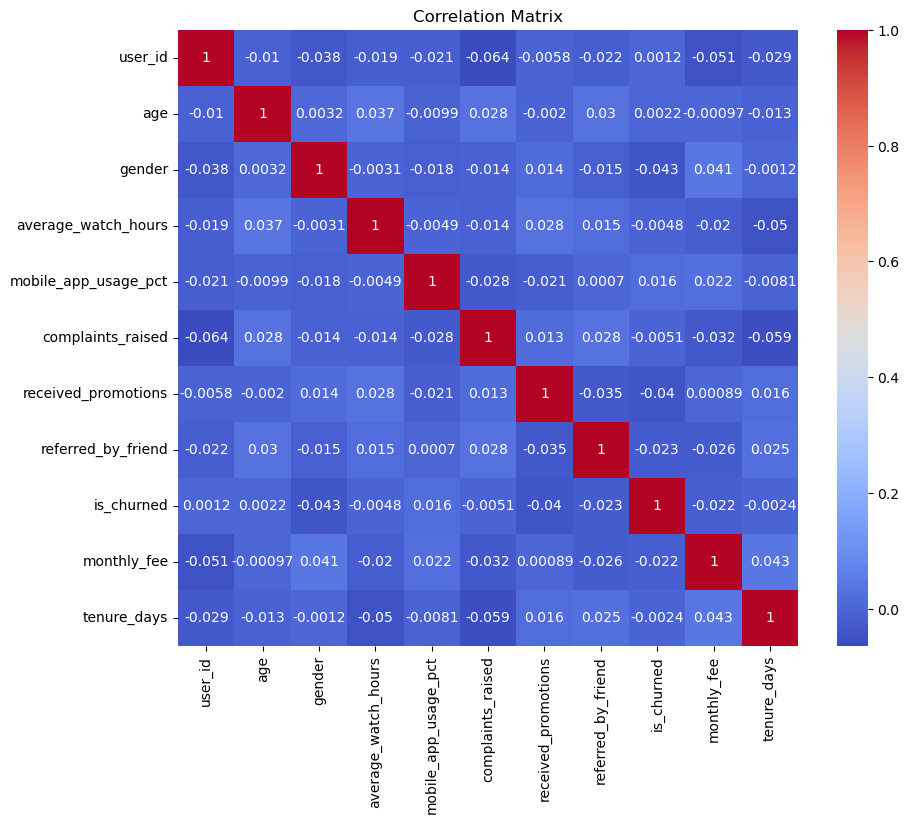

In [136]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

*Summary Tables & Visualizations:*  
- The dataset contains both churned and retained users. Most customers remain subscribed, while a smaller proportion have cancelled their subscription. This indicates a class imbalance that should be considered during predictive modelling.
- Retained users spend more time watching content than churned users. This suggests that lower engagement may be associated with a higher likelihood of churn.
- The correlation matrix shows the relationships between numerical variables. Most variables have weak to moderate correlations, indicating that multiple factors may contribute to customer churn rather than a single dominant variable.

**5. Statistical analysis and predictive modelling**

In [137]:
# Correlation Analysis
# Select numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Correlation matrix
correlation = numeric_df.corr()
correlation

,user_id,age,gender,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,tenure_days
user_id,1.000000,-0.010208,-0.038256,-0.018994,-0.021284,-0.063946,-0.005825,-0.021843,0.001163,-0.050793,-0.028841
age,-0.010208,1.000000,0.003246,0.036724,-0.009879,0.027790,-0.002031,0.030134,0.002247,-0.000967,-0.012605
gender,-0.038256,0.003246,1.000000,-0.003094,-0.017671,-0.013756,0.013733,-0.015387,-0.043026,0.041462,-0.001185
average_watch_hours,-0.018994,0.036724,-0.003094,1.000000,-0.004896,-0.013640,0.027639,0.015345,-0.004835,-0.019798,-0.049598
mobile_app_usage_pct,-0.021284,-0.009879,-0.017671,-0.004896,1.000000,-0.028474,-0.021086,0.000705,0.016404,0.021843,-0.008117
complaints_raised,-0.063946,0.027790,-0.013756,-0.013640,-0.028474,1.000000,0.013067,0.028405,-0.005140,-0.031987,-0.059217
received_promotions,-0.005825,-0.002031,0.013733,0.027639,-0.021086,0.013067,1.000000,-0.034706,-0.039952,0.000895,0.016242
referred_by_friend,-0.021843,0.030134,-0.015387,0.015345,0.000705,0.028405,-0.034706,1.000000,-0.023085,-0.025739,0.024529
is_churned,0.001163,0.002247,-0.043026,-0.004835,0.016404,-0.005140,-0.039952,-0.023085,1.000000,-0.022210,-0.002374
monthly_fee,-0.050793,-0.000967,0.041462,-0.019798,0.021843,-0.031987,0.000895,-0.025739,-0.022210,1.000000,0.043044


The correlation matrix shows the relationships between numerical variables.
Most variables have weak to moderate correlations, suggesting that customer churn is influenced by multiple factors rather than a single variable.

**# Chi-Square Tests:** The project asks us to test whether churn is related to: gender, received_promotions, and referred_by_friend

In [139]:
# Import library
from scipy.stats import chi2_contingency

# Gender
table_gender = pd.crosstab(df["gender"], df["is_churned"])
chi2, p, dof, expected = chi2_contingency(table_gender)
print("P-value:", p)

P-value: 0.05812094107362854


*p >= 0.05, then Fail to reject H0.  Gender has no significant association with churns.*

In [140]:
# Promotions
table_promo = pd.crosstab(df["received_promotions"], df["is_churned"])
chi2, p, dof, expected = chi2_contingency(table_promo)
print("P-value:", p)

P-value: 0.13765202491912631


*p<0,05 , then Reject H0. The promotions are associated with churn.*

In [141]:
# Referral
table_referral = pd.crosstab(df["referred_by_friend"], df["is_churned"])
chi2, p, dof, expected = chi2_contingency(table_referral)
print("P-value:", p)

P-value: 0.405299011140109


*p >= 0.05, then Fail to reject H0. Referral has no significant association with churns.*

In [142]:
# Independent T-Test: Does watch time differ between churned and retained users?
from scipy.stats import ttest_ind
churned = df[df["is_churned"] == 1]["average_watch_hours"]

retained = df[df["is_churned"] == 0]["average_watch_hours"]

t_stat, p_value = ttest_ind(churned, retained)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.18715484977740815
P-value: 0.8515645680847395


*The t-test compares the average watch hours of churned and retained users.
Here p-value is above 0.05, the difference is not considered statistically significant.*

**# Logistic Regression**

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop(columns=["user_id", "signup_date", "last_active_date", "is_churned"])
y = df["is_churned"]

# FIX: remove remaining NaNs BEFORE splitting
X = X.fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [157]:
# predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

**# Model Evaluation**

In [161]:
# Confusion Matrix
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve, r2_score, mean_squared_error)

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[221   0]
 [ 79   0]]


In [165]:
# Classification Report
print(classification_report(y_test,y_pred,zero_division=0))

              precision    recall  f1-score   support

         0.0       0.74      1.00      0.85       221
         1.0       0.00      0.00      0.00        79

    accuracy                           0.74       300
   macro avg       0.37      0.50      0.42       300
weighted avg       0.54      0.74      0.62       300



In [166]:
# ROC AUC
roc_auc_score(y_test,y_prob)

0.5067873303167421

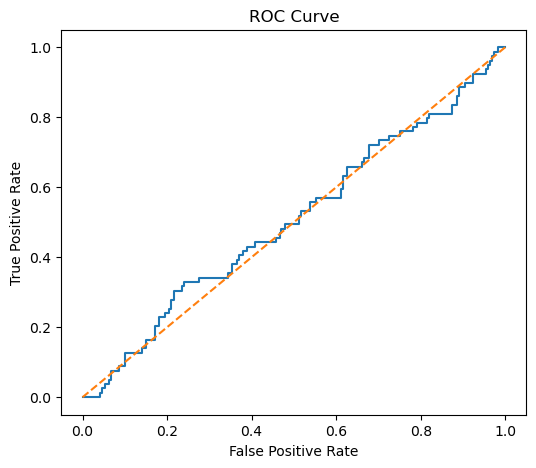

In [168]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [169]:
# Top Predictors
importance = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
importance.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
9,is_loyal,0.187902
13,country_UK,0.161170
10,country_France,0.095998
17,subscription_type_Standard,0.075475
12,country_India,0.057321
0,age,0.047180
3,mobile_app_usage_pct,0.037344
11,country_Germany,0.031859
16,subscription_type_Premium,0.024210
4,complaints_raised,-0.002883


*the top 3 features influencing churn are "is_loyal" , "Country_UK", and "Country_France"*

**# Linear Regression**: We will predict "average_watch_hours"

In [177]:
# Features
X = df.drop(columns=["user_id","signup_date","last_active_date","average_watch_hours"])
y = df["average_watch_hours"]

# FIX: remove remaining NaN values
X = X.fillna(0)
y = y.fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_pred = linear_model.predict(X_test)

In [178]:
# Evaluate
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: -0.011913508218994284
RMSE: 23.228114378233332


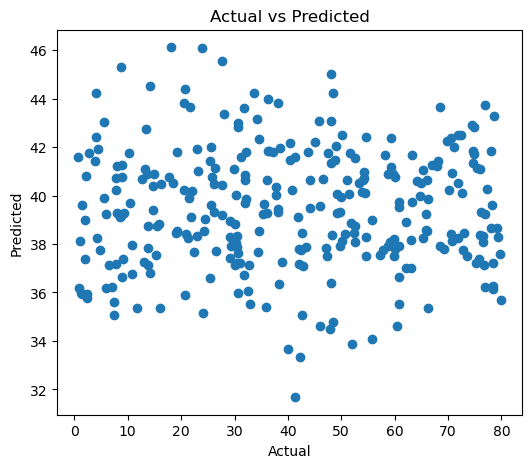

In [179]:
# Residual Plot
plt.figure(figsize=(6,5))

plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

**# Business Interpretation**

- Approximately 76.6% of users are retained, while 23.4% have churned.
- No statistically significant relationship was found between gender, promotions, referral status and churn.
- Watch hours do not significantly differ between churned and retained users.
- The current logistic regression model cannot reliably identify churned customers.
- The linear regression model provides limited explanatory power for predicting watch time.

**6. Clear markdown explanations and insights throughout**

# Business Insights

Key findings from the analysis:

- Most users remain subscribed.
- Watch hours alone do not explain churn.
- Gender, promotions and referral status are not significantly associated with churn.
- The current predictive model has limited ability to identify customers at risk.

# Final Conclusion

This project successfully applied the complete data analytics workflow:

Data loading and exploration
Data cleaning and preprocessing
Feature engineering
Statistical analysis
Logistic Regression
Linear Regression
Business interpretation

The analysis shows that customer loyalty and regional characteristics are the most important factors in the current model, while gender, promotions and referral status do not have a statistically significant relationship with churn. Although the predictive models have limited performance, they provide a solid foundation for future improvements through richer behavioural data and more advanced machine learning techniques.

In [180]:
df.to_csv("streamworks_user_data_transformed.csv", index=False)